# Python Data Processing and Analysis

This notebook uses Python to clean, process, and analyse the NorthStar dataset. The aim is to identify delivery performance issues, complaint patterns, incident trends, and operational cost problems using Pandas and visualisations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

deliveries = pd.read_csv("deliveries.csv")
orders = pd.read_csv("orders.csv")
complaints = pd.read_csv("complaints.csv")
incidents = pd.read_csv("incidents.csv")

print("Deliveries shape:", deliveries.shape)
print("Orders shape:", orders.shape)
print("Complaints shape:", complaints.shape)
print("Incidents shape:", incidents.shape)

Deliveries shape: (950, 13)
Orders shape: (1250, 11)
Complaints shape: (320, 10)
Incidents shape: (280, 7)


In [2]:
print("Deliveries columns:")
print(deliveries.columns)

print("\nOrders columns:")
print(orders.columns)

print("\nComplaints columns:")
print(complaints.columns)

print("\nIncidents columns:")
print(incidents.columns)

Deliveries columns:
Index(['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id',
       'dispatch_time', 'delivery_completed_at', 'delivery_status',
       'route_distance_km', 'manual_route_override_count',
       'proof_of_completion_missing', 'customer_rating_post_delivery',
       'fuel_or_charge_cost'],
      dtype='object')

Orders columns:
Index(['order_id', 'customer_id', 'service_type', 'order_created_at',
       'promised_window_hours', 'pickup_zone', 'dropoff_zone',
       'priority_level', 'order_value', 'booking_channel',
       'special_handling_flag'],
      dtype='object')

Complaints columns:
Index(['complaint_id', 'customer_id', 'order_id', 'complaint_type', 'channel',
       'severity', 'created_at', 'status', 'resolution_days',
       'compensation_amount'],
      dtype='object')

Incidents columns:
Index(['incident_id', 'delivery_id', 'incident_type', 'reported_at',
       'severity', 'resolution_status', 'resolved_hours'],
      dtype='object')


## Data Quality Check

The first step was to check the dataset size, column names, and missing values. This helps identify whether the dataset needs cleaning before analysis.

## Missing Value Analysis

In [3]:
import numpy as np

delivery_costs = deliveries["fuel_or_charge_cost"].dropna()

average_cost = np.mean(delivery_costs)
maximum_cost = np.max(delivery_costs)
minimum_cost = np.min(delivery_costs)
standard_deviation = np.std(delivery_costs)

print("Average Cost:", average_cost)
print("Maximum Cost:", maximum_cost)
print("Minimum Cost:", minimum_cost)
print("Standard Deviation:", standard_deviation)

Average Cost: 12.841294736842105
Maximum Cost: 29.43
Minimum Cost: 2.5
Standard Deviation: 4.3341853732820805


      Dataset  Missing Values
0  deliveries              33
1      orders              25
2  complaints              16
3   incidents              17


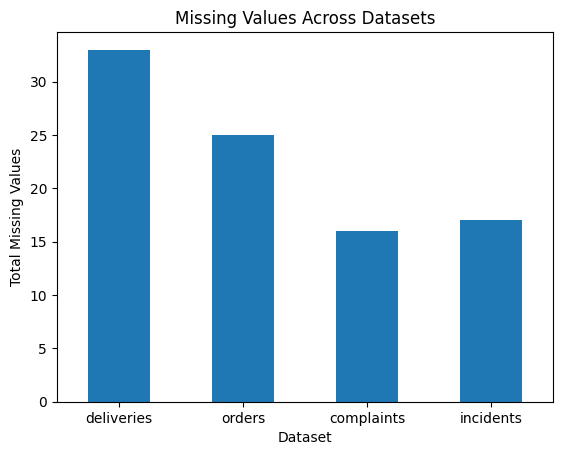

In [4]:
missing_counts = {
    "deliveries": deliveries.isnull().sum().sum(),
    "orders": orders.isnull().sum().sum(),
    "complaints": complaints.isnull().sum().sum(),
    "incidents": incidents.isnull().sum().sum()
}

missing_df = pd.DataFrame(
    list(missing_counts.items()),
    columns=["Dataset", "Missing Values"]
)

print(missing_df)

missing_df.plot(
    kind="bar",
    x="Dataset",
    y="Missing Values",
    legend=False
)

plt.title("Missing Values Across Datasets")
plt.xlabel("Dataset")
plt.ylabel("Total Missing Values")
plt.xticks(rotation=0)
plt.show()

The analysis identifies differences in missing value distribution across major operational datasets. Datasets with larger numbers of missing values may reduce analytical reliability and indicate weaknesses in data collection, integration, or operational reporting processes. Identifying missing data is important because incomplete operational records may affect decision-making accuracy and limit the organisation’s ability to monitor service performance effectively.

## Delivery Performance Analysis

delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64


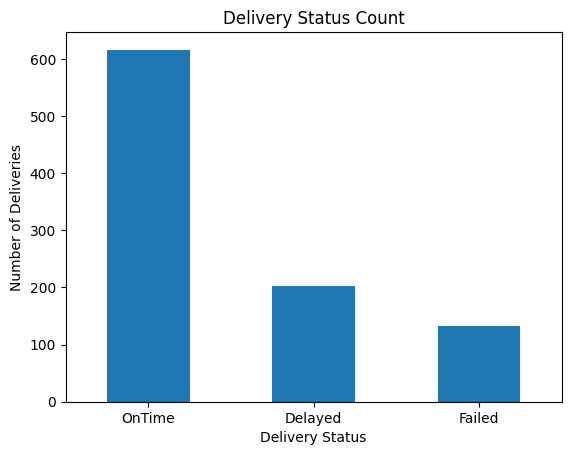

In [5]:
delivery_status = deliveries["delivery_status"].value_counts()
print(delivery_status)

delivery_status.plot(kind="bar")
plt.title("Delivery Status Count")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Deliveries")
plt.xticks(rotation=0)
plt.show()

The delivery status analysis shows that although most deliveries were completed on time, delayed and failed deliveries still form a noticeable part of the operations. This supports the issue that NorthStar is facing service reliability challenges.

## Complaint Cost Analysis

severity
Low        9.056000
Medium    17.365120
High      38.847941
Name: compensation_amount, dtype: float64


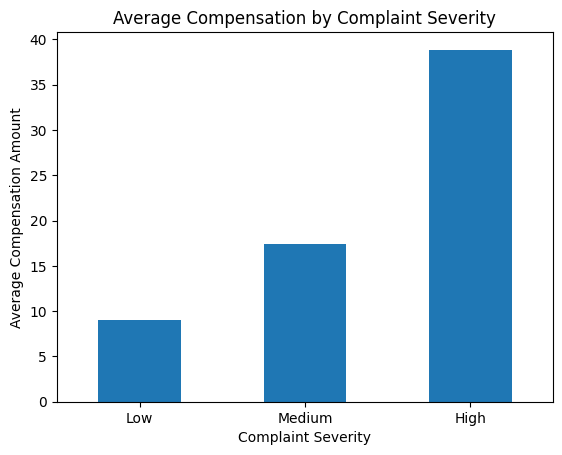

In [6]:
severity_order = ["Low", "Medium", "High"]

complaint_cost = complaints.groupby("severity")["compensation_amount"].mean().reindex(severity_order)

print(complaint_cost)

complaint_cost.plot(kind="bar")
plt.title("Average Compensation by Complaint Severity")
plt.xlabel("Complaint Severity")
plt.ylabel("Average Compensation Amount")
plt.xticks(rotation=0)
plt.show()

The complaint analysis shows that higher severity complaints are linked with higher average compensation. This suggests that serious service failures have a direct financial impact on the organisation.

## Incident Resolution Analysis

resolution_status
Closed           122
Open              77
PendingVendor     46
Escalated         35
Name: count, dtype: int64


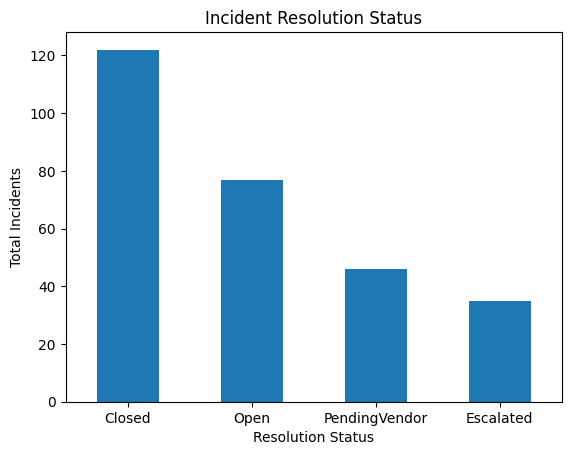

In [7]:
status_order = ["Closed", "Open", "PendingVendor", "Escalated"]

incident_resolution = incidents["resolution_status"].value_counts().reindex(status_order)

print(incident_resolution)

incident_resolution.plot(kind="bar")
plt.title("Incident Resolution Status")
plt.xlabel("Resolution Status")
plt.ylabel("Total Incidents")
plt.xticks(rotation=0)
plt.show()

The incident analysis shows that a large number of operational incidents remain open or escalated. This may affect delivery efficiency, customer satisfaction, and operational reliability across the organisation.

## Delivery Status and Customer Rating Analysis

delivery_status
OnTime     4.283273
Delayed    3.114975
Failed     3.049313
Name: customer_rating_post_delivery, dtype: float64


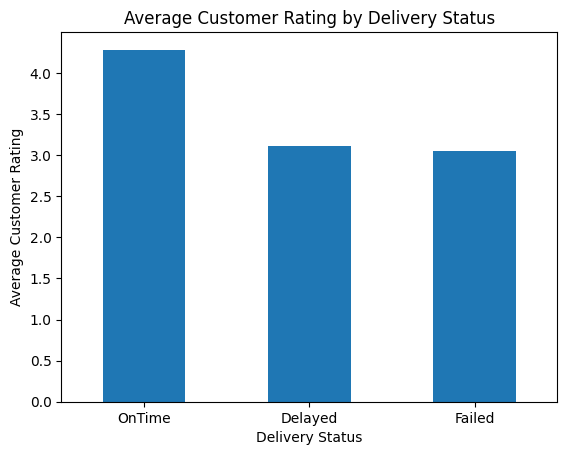

In [8]:
rating_by_status = deliveries.groupby("delivery_status")["customer_rating_post_delivery"].mean().sort_values(ascending=False)

print(rating_by_status)

rating_by_status.plot(kind="bar")
plt.title("Average Customer Rating by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Customer Rating")
plt.xticks(rotation=0)
plt.show()

This analysis examines whether delivery outcomes affect customer satisfaction by comparing average customer ratings across delivery status categories.

## Delivery Cost by Delivery Status

delivery_status
Failed     13.147955
Delayed    13.138713
OnTime     12.678052
Name: fuel_or_charge_cost, dtype: float64


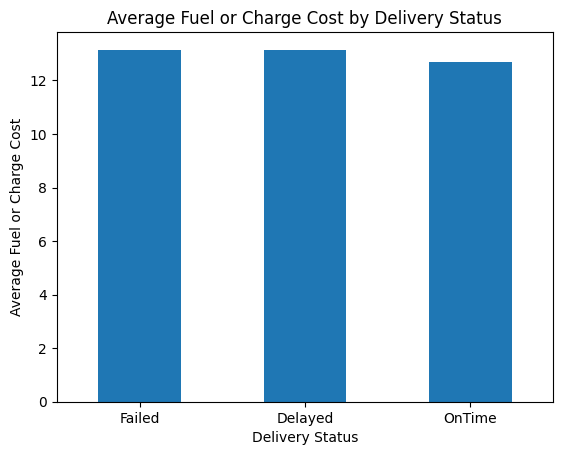

In [9]:
cost_by_status = deliveries.groupby("delivery_status")["fuel_or_charge_cost"].mean().sort_values(ascending=False)

print(cost_by_status)

cost_by_status.plot(kind="bar")
plt.title("Average Fuel or Charge Cost by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Fuel or Charge Cost")
plt.xticks(rotation=0)
plt.show()

This analysis compares average fuel or charging costs across delivery status categories to examine whether failed or delayed deliveries are linked with higher operational costs.

## Complaint Resolution Time Analysis

severity
High      13.116883
Low        6.563380
Medium     6.168605
Name: resolution_days, dtype: float64


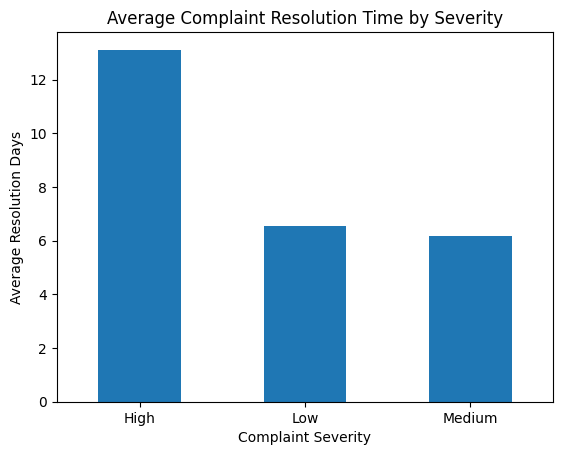

In [10]:
resolution_analysis = complaints.groupby("severity")["resolution_days"].mean().sort_values(ascending=False)

print(resolution_analysis)

resolution_analysis.plot(kind="bar")
plt.title("Average Complaint Resolution Time by Severity")
plt.xlabel("Complaint Severity")
plt.ylabel("Average Resolution Days")
plt.xticks(rotation=0)
plt.show()

This analysis examines how complaint resolution time differs across complaint severity levels to identify whether more serious complaints require longer resolution periods.

## Delivery Distance and Service Outcome Analysis

delivery_status
Delayed    14.670248
OnTime     13.776364
Failed     13.365303
Name: route_distance_km, dtype: float64


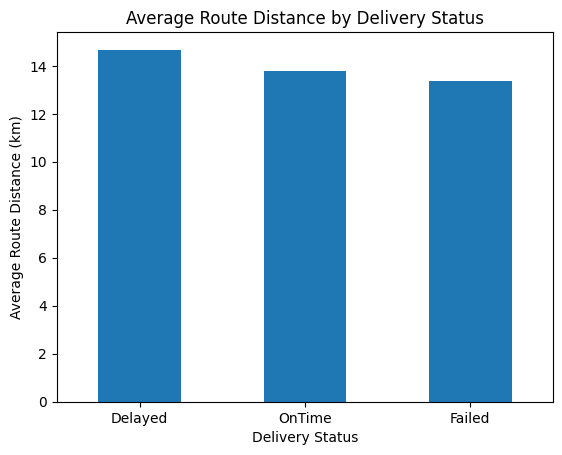

In [11]:
distance_analysis = deliveries.groupby("delivery_status")["route_distance_km"].mean().sort_values(ascending=False)

print(distance_analysis)

distance_analysis.plot(kind="bar")
plt.title("Average Route Distance by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Route Distance (km)")
plt.xticks(rotation=0)
plt.show()

This analysis examines whether delivery distance influences delivery outcomes by comparing average route distance across different delivery status categories.

## Summary of Python Analysis

Python analysis identified several operational patterns within the NorthStar dataset. Delivery delays, failed deliveries, unresolved incidents, and high-severity complaints all contribute to operational inefficiencies and customer dissatisfaction. The analysis also highlighted variations in route distances and compensation costs, supporting the need for improved operational monitoring and data-driven decision-making.